<a href="https://www.kaggle.com/code/siryorch/ups-writing-skills-jcueva-kyansaguano?scriptVersionId=292246652" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/ups-writing-skills/all-images/.directory
/kaggle/input/ups-writing-skills/all-images/triangle/t9i-0.PNG
/kaggle/input/ups-writing-skills/all-images/triangle/t5-1.PNG
/kaggle/input/ups-writing-skills/all-images/triangle/t10c-2.PNG
/kaggle/input/ups-writing-skills/all-images/triangle/t15ni-2.PNG
/kaggle/input/ups-writing-skills/all-images/triangle/t11ci-1.PNG
/kaggle/input/ups-writing-skills/all-images/triangle/t14n-1.PNG
/kaggle/input/ups-writing-skills/all-images/triangle/t12-2.PNG
/kaggle/input/ups-writing-skills/all-images/triangle/t14ni-2.PNG
/kaggle/input/ups-writing-skills/all-images/triangle/t12ni-1.PNG
/kaggle/input/ups-writing-skills/all-images/triangle/t13-2.PNG
/kaggle/input/ups-writing-skills/all-images/triangle/t7-2.PNG
/kaggle/input/ups-writing-skills/all-images/triangle/t6n-2.PNG
/kaggle/input/ups-writing-skills/all-images/triangle/t15n-1.PNG
/kaggle/input/ups-writing-skills/all-images/triangle/t7i-1.PNG
/kaggle/input/ups-writing-skills/all-images/triangle/t

In [2]:
import cv2
import numpy as np

def noise_gauss(image, nivel=2):
    if nivel == 1:
        mean, sigma = 0, 10
    elif nivel == 2:
        mean, sigma = 0, 25
    elif nivel == 3:
        mean, sigma = 0, 50

    image_float = image.astype(np.float32)

    gaussian_noise = np.random.normal(mean, sigma, image.shape)
    noisy_image = image_float + gaussian_noise

    noisy_image = np.clip(noisy_image, 0, 255)
    return noisy_image.astype(np.uint8)


def noise_sp(image , nivel=2):
    if nivel == 1:
        salt = 0.01
        pepper = 0.01
    elif nivel == 2:
        salt = 0.02
        pepper = 0.02
    elif nivel == 3:
        salt = 0.04
        pepper = 0.04
    else:
        raise ValueError("nivel debe ser 1, 2 o 3")
    
    noisy_image = image.copy()
    h, w = image.shape[:2]

    total_pixels = h * w

    num_salt = int(total_pixels * salt)
    num_pepper = int(total_pixels * pepper)

    # Sal (blanco)
    coords = (
        np.random.randint(0, h, num_salt),
        np.random.randint(0, w, num_salt)
    )
    noisy_image[coords] = 255

    # Pimienta (negro)
    coords = (
        np.random.randint(0, h, num_pepper),
        np.random.randint(0, w, num_pepper)
    )
    noisy_image[coords] = 0

    return noisy_image

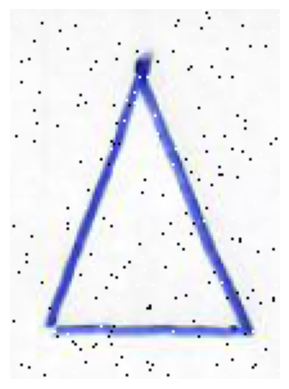

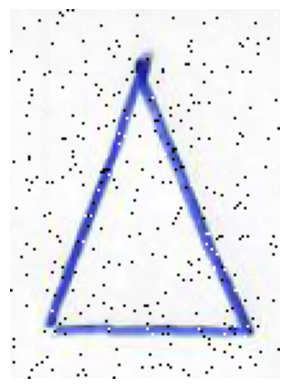

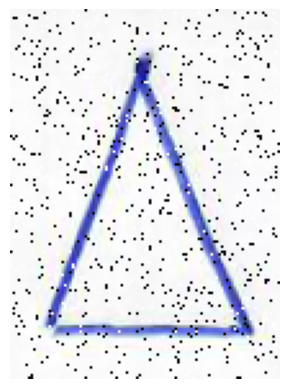

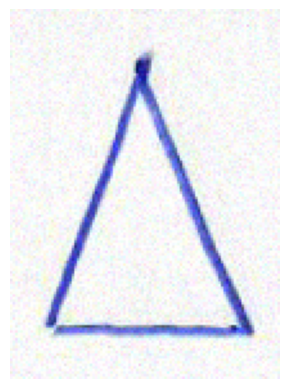

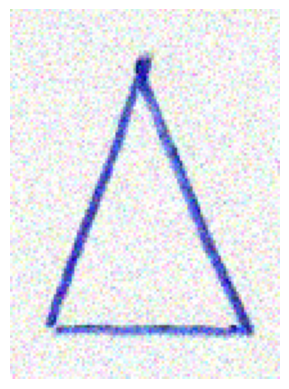

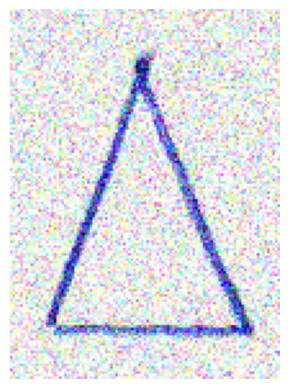

In [3]:
import matplotlib.pyplot as plt
import cv2

def show_image(img):
    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img)
    plt.axis("off")
    plt.show()

img = cv2.imread("/kaggle/input/ups-writing-skills/all-images/triangle/t10c-2.PNG")

# pruebas de ruido


img_3 = noise_sp(img,1)
img_1 = noise_sp(img,2)
img_2 = noise_sp(img,3)
show_image(img_3)
show_image(img_1)
show_image(img_2)

img = noise_gauss(img,1)
img_1 = noise_gauss(img,2)
img_2 = noise_gauss(img,3)
show_image(img)
show_image(img_1)
show_image(img_2)
